In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [1]:
import yfinance as yf
import pandas as pd

# Download 1 year of stock data for 3 companies
stocks = ['AAPL', 'TSLA', 'INFY']  # Apple, Tesla, Infosys (Indian stock!)

data = {}
for stock in stocks:
    data[stock] = yf.download(stock, start='2024-01-01', end='2025-01-01')
    print(f"✅ {stock} — {len(data[stock])} days of data downloaded")

# Preview Apple's data
print("\n--- Sample of AAPL data ---")
print(data['AAPL'].tail())

[*********************100%***********************]  1 of 1 completed


✅ AAPL — 252 days of data downloaded


[*********************100%***********************]  1 of 1 completed


✅ TSLA — 252 days of data downloaded


[*********************100%***********************]  1 of 1 completed

✅ INFY — 252 days of data downloaded

--- Sample of AAPL data ---
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-12-24  256.797180  256.807105  253.902972  254.101897  23234700
2024-12-26  257.612701  258.686851  256.230269  256.787224  27237100
2024-12-27  254.201370  257.294489  251.685117  256.429191  42355300
2024-12-30  250.829773  252.122713  249.387654  250.859609  35557500
2024-12-31  249.059464  251.903926  248.074837  251.068493  39480700


In [5]:
for stock in stocks:
    data[stock]['Daily Return'] = data[stock]['Close'].pct_change() * 100

# 2. Moving Averages — smooths out the noise to show the trend
for stock in stocks:
    data[stock]['MA20']  = data[stock]['Close'].rolling(window=20).mean()   # 20-day average
    data[stock]['MA50']  = data[stock]['Close'].rolling(window=50).mean()   # 50-day average

# 3. Summary statistics for each stock
print("=" * 50)
for stock in stocks:
    close = data[stock]['Close'].squeeze()  # fixes the shape issue
    ret   = data[stock]['Daily Return'].squeeze()
    print(f"\n📊 {stock}")
    print(f"   Price Range  : ${close.min():.2f}  →  ${close.max():.2f}")
    print(f"   Avg Daily Return : {ret.mean():.3f}%")
    print(f"   Volatility (std) : {ret.std():.3f}%")
    print(f"   Best Day  : +{ret.max():.2f}%")
    print(f"   Worst Day :  {ret.min():.2f}%")
print("=" * 50)


📊 AAPL
   Price Range  : $163.51  →  $257.61
   Avg Daily Return : 0.131%
   Volatility (std) : 1.412%
   Best Day  : +7.26%
   Worst Day :  -4.82%

📊 TSLA
   Price Range  : $142.05  →  $479.86
   Avg Daily Return : 0.272%
   Volatility (std) : 4.008%
   Best Day  : +21.92%
   Worst Day :  -12.33%

📊 INFY
   Price Range  : $15.54  →  $22.75
   Avg Daily Return : 0.099%
   Volatility (std) : 1.431%
   Best Day  : +8.38%
   Worst Day :  -4.46%


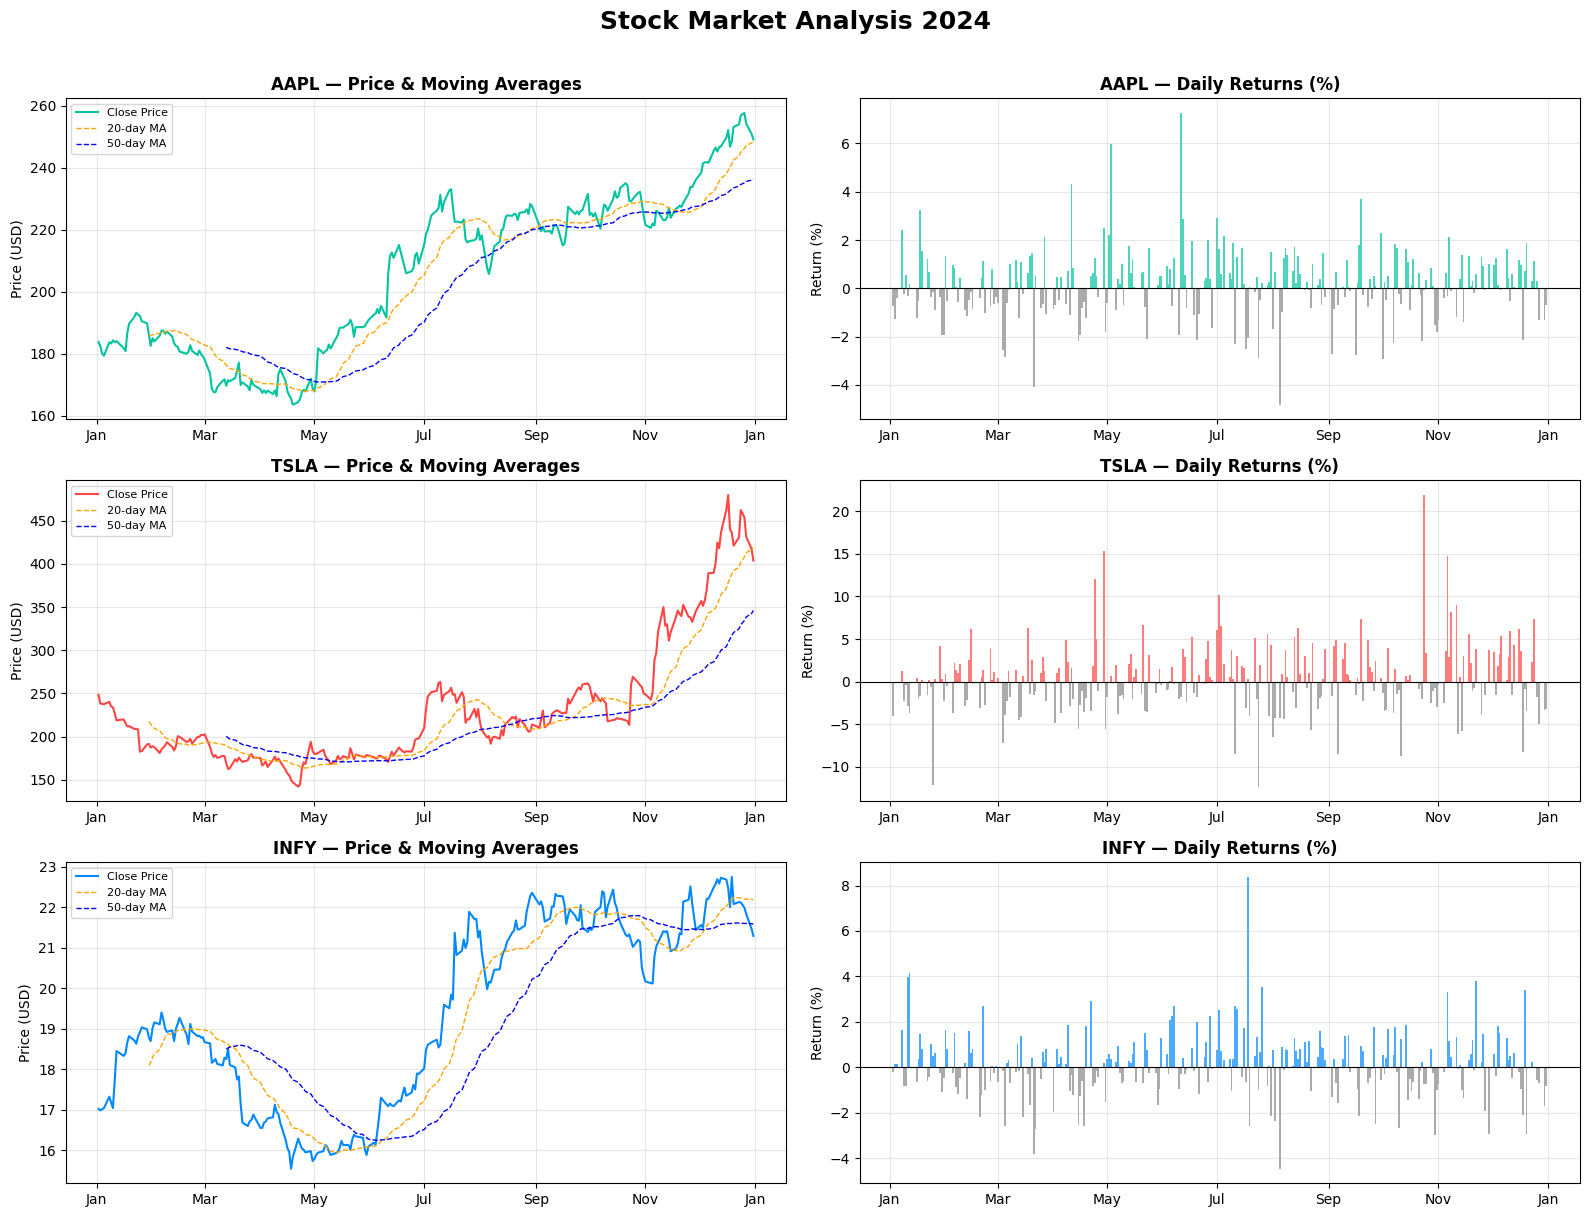

✅ Chart saved as stock_analysis.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Stock Market Analysis 2024', fontsize=18, fontweight='bold', y=1.01)

colors = {'AAPL': '#00C49F', 'TSLA': '#FF4444', 'INFY': '#0088FE'}

for i, stock in enumerate(stocks):
    df    = data[stock]
    close = df['Close'].squeeze()
    ret   = df['Daily Return'].squeeze()
    ma20  = df['MA20'].squeeze()
    ma50  = df['MA50'].squeeze()

    # --- Left column: Price + Moving Averages ---
    ax1 = axes[i, 0]
    ax1.plot(df.index, close, color=colors[stock], linewidth=1.5, label='Close Price')
    ax1.plot(df.index, ma20,  color='orange',       linewidth=1,   linestyle='--', label='20-day MA')
    ax1.plot(df.index, ma50,  color='blue',          linewidth=1,   linestyle='--', label='50-day MA')
    ax1.set_title(f'{stock} — Price & Moving Averages', fontweight='bold')
    ax1.set_ylabel('Price (USD)')
    ax1.legend(fontsize=8)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax1.grid(True, alpha=0.3)

    # --- Right column: Daily Returns ---
    ax2 = axes[i, 1]
    ret_clean = ret.dropna()
    ax2.bar(df.index[1:], ret.dropna(),
            color=[colors[stock] if x >= 0 else '#888888' for x in ret_clean],
            alpha=0.7, width=1)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_title(f'{stock} — Daily Returns (%)', fontweight='bold')
    ax2.set_ylabel('Return (%)')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stock_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as stock_analysis.png")

In [7]:
# ---- FINAL INSIGHTS ----

print("=" * 55)
print("       📈 STOCK ANALYSIS REPORT — 2024")
print("=" * 55)

best_stock = None
best_return = -999

for stock in stocks:
    close  = data[stock]['Close'].squeeze()
    ret    = data[stock]['Daily Return'].squeeze()

    total_return = ((close.iloc[-1] - close.iloc[0]) / close.iloc[0]) * 100
    volatility   = ret.std()

    print(f"\n🏢 {stock}")
    print(f"   Total Return  : {total_return:+.2f}% over 2024")
    print(f"   Volatility    : {volatility:.2f}% daily std dev")
    print(f"   Risk/Reward   : {'⚠️ High Risk' if volatility > 2 else '✅ Moderate Risk'}")

    if total_return > best_return:
        best_return = total_return
        best_stock  = stock

print("\n" + "=" * 55)
print(f"🏆 Best Performer : {best_stock} with {best_return:+.2f}% return")
print("=" * 55)

print("""
📝 KEY FINDINGS:
  1. Moving average crossovers signal trend changes
  2. Higher volatility = higher risk but higher reward
  3. Diversifying across sectors reduces overall risk
  4. INFY shows Indian market exposure vs US tech stocks
""")

       📈 STOCK ANALYSIS REPORT — 2024

🏢 AAPL
   Total Return  : +35.56% over 2024
   Volatility    : 1.41% daily std dev
   Risk/Reward   : ✅ Moderate Risk

🏢 TSLA
   Total Return  : +62.56% over 2024
   Volatility    : 4.01% daily std dev
   Risk/Reward   : ⚠️ High Risk

🏢 INFY
   Total Return  : +25.11% over 2024
   Volatility    : 1.43% daily std dev
   Risk/Reward   : ✅ Moderate Risk

🏆 Best Performer : TSLA with +62.56% return

📝 KEY FINDINGS:
  1. Moving average crossovers signal trend changes
  2. Higher volatility = higher risk but higher reward
  3. Diversifying across sectors reduces overall risk
  4. INFY shows Indian market exposure vs US tech stocks



In [8]:
print("✅ Project Complete!")
print("📁 Your chart is saved as: stock_analysis.png")
print("📓 Save this notebook: File → Save Notebook")
print("\n🚀 To share on GitHub:")
print("   1. Go to github.com → New Repository → 'stock-analysis'")
print("   2. Upload this .ipynb file + stock_analysis.png")
print("   3. Add a README: 'Stock Market Analysis using Python & yfinance'")
print("   4. Share the link on your LinkedIn/Resume!")


✅ Project Complete!
📁 Your chart is saved as: stock_analysis.png
📓 Save this notebook: File → Save Notebook

🚀 To share on GitHub:
   1. Go to github.com → New Repository → 'stock-analysis'
   2. Upload this .ipynb file + stock_analysis.png
   3. Add a README: 'Stock Market Analysis using Python & yfinance'
   4. Share the link on your LinkedIn/Resume!
